# Diagrama de Entidade Relacionamento (DER)

## O que é exatamente?

- É uma abstração visual da base de dados de um programa, onde há um relacionamento entre as entidades.
- **Entidades:** São os retângulos.
- **Relacionamentos:** São as linhas.

> **Um detalhe importante:** As linhas tem especificações, ou seja, o ponto inicial e final de uma linha em relação a entidade tem um significado, que será abordado em breve.

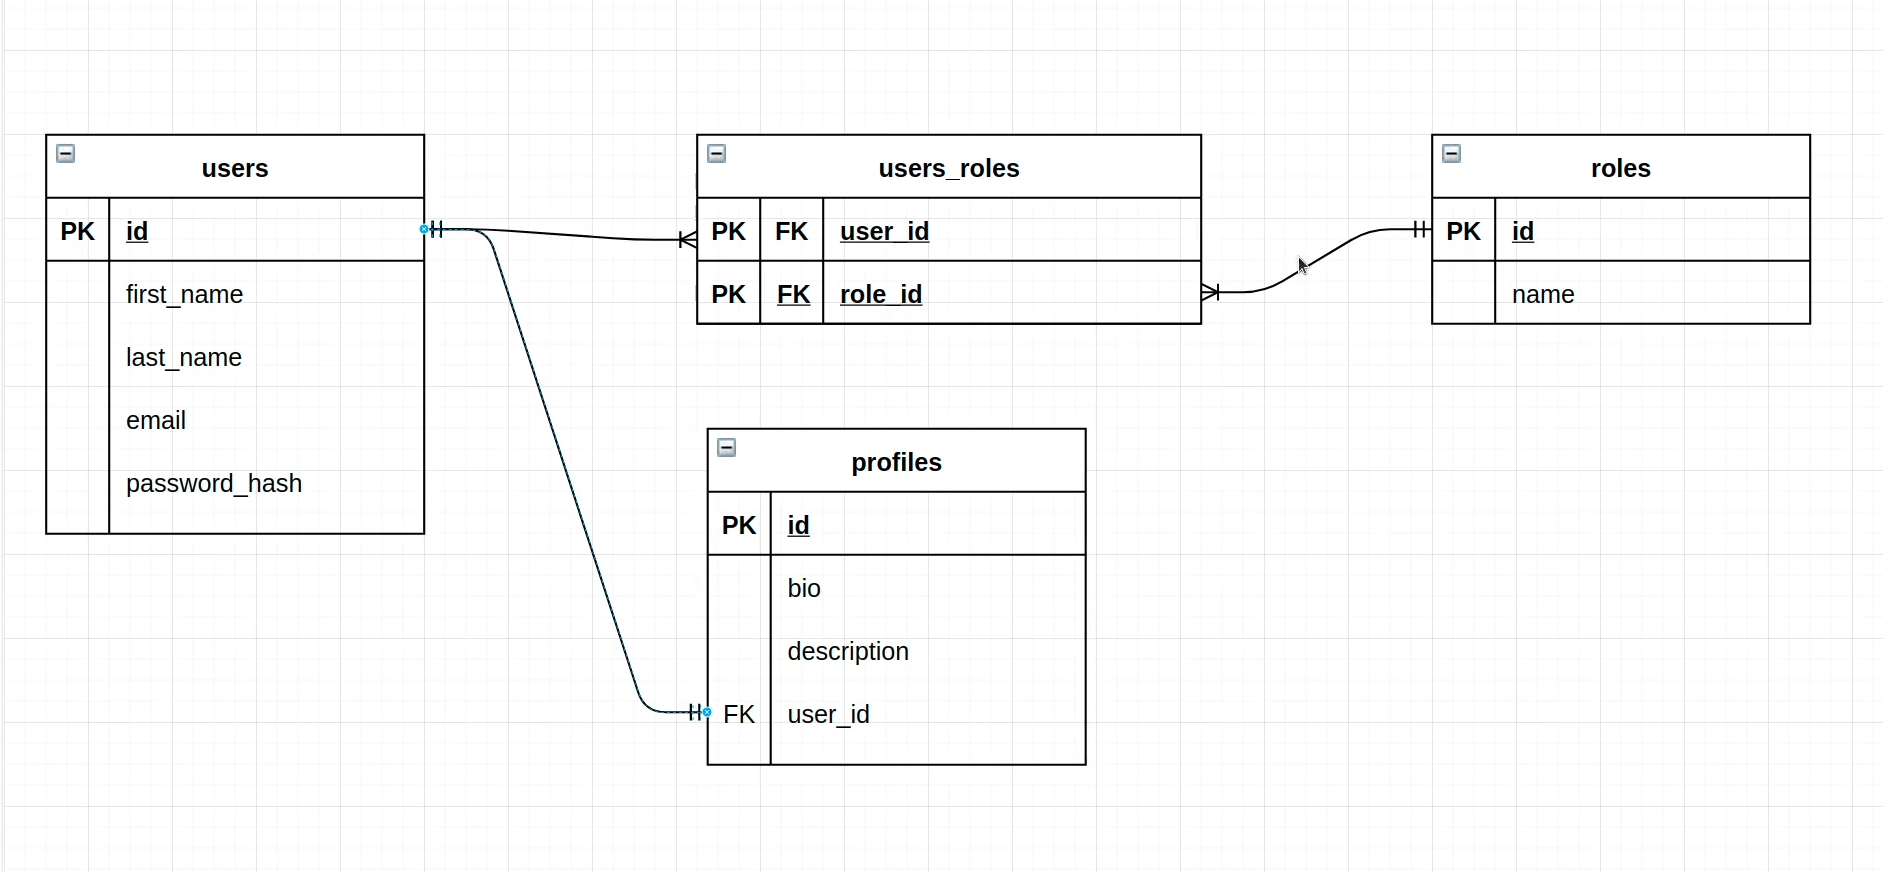

---

## Como funciona exatamente?

Como foi dito antes, **entidade é um retângulo**, que representa uma tabela no banco de dados. No entanto, há diversos tipos de entidades, como entidades fortes, fracas, associativa, dentre outras. Porém, no momento, vamos esquecer isso e focar somente em 'entidades'.

### Estrutura da Tabela
Na tabela *user* mostrada anteriormente, temos alguns dados. No entanto, como se trata de uma abstração, não é necessário passar todos os dados presentes na tabela, apenas os essenciais.

Portanto, há somente os seguintes campos: `id`, `first_name`, `last_name`, `email` e `password_hash` e todas as outras tabelas tem as suas colunas. Todos eles são apenas colunas, sendo semelhante ao próprio excel, veja como:

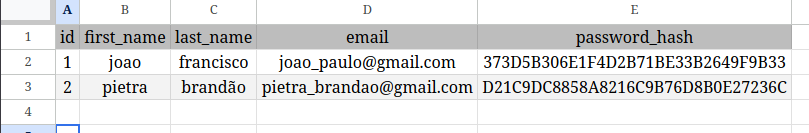

### Entendendo a Primary Key (PK)

uando reparamos na tabela acima, há algo denominado de **id**, que se olharmos atentamente no DER acima, há uma sigla **(PK)**.
* Isso é o identificador único da tabela, denominado de **Primary Key (Chave primária)**.
* Através dessa chave primária é possível encontrar dados específicos em uma tabela gigantesca e fora isso, inibe alguns conflitos de dados.

Portanto, o valor da chave primária deve ser **único para cada linha** na composição da tabela. Ademais, se olhar na imagem acima, vai perceber também que a cada linha (registro) tem seu identificador único na tabela.

> **Obs:** É possível buscar uma informação utilizando valores que não são primary key também na tabela, porém, nem sempre acaba sendo tão eficaz quanto uma primary key.

### As 5 restrições da Primary Key
Ademais, para primary key há 5 restrições:
1.  O valor da Primary Key **não pode ser nulo**.
2.  **Não pode repetir o valor** da primary key na tabela.
3.  **Não pode repetir a coluna** Primary key na tabela.
4.  Ela **não pode mudar** (até pode, vou explicar abaixo).
5.  Ela tem que ser **única**.

### Comportamento (Enumeração e Auto-increment)
Um detalhe importante sobre a primary key é que é difícil para mudar o valor da Primary key, pois normalmente há uma enumeração (como visto na print do sheets).

Ademais, se por acaso uma tabela que tem Primary Key for completamente limpa, a enumeração da Primary Key irá continuar de forma descente através do auto-increment, continuando do último ponto de registro:
* Ou seja, se antes parou em 55, mesmo limpando a tabela, o padrão é a Primary Key seguir em diante na próxima adição, sendo **56**. Porém, isso não é um problema, pois não vai interferir na lógica ou funcionamento da tabela. No mais, é uma forma de evitar um problema, pois se um usuário for apagado da base por algum motivo desconhecido, será mais fácil de identificar.

> **Pra deixar claro:** Caso você tenha uma tabela contendo 100 pessoas preenchidas e acabar apagando a pessoa 100, o auto-increment vai considerar que a pessoa 100 ainda existe. Ou seja, quando a próxima pessoa for criada, seu id não será 100 (substituindo o anterior), ele será **101**.

* Isso não é um problema, pois é mais por questão de organização mesmo. No entanto, caso seja necessário fazer isso manualmente, normalmente é utilizado um **UUID** (Universally Unique Identifier), que é um algoritmo que gera uma string alfanumérica (normalmente de 128 bits) que pode ser usado para gerar um identificador único. **Ex: 550e8400-e29b-41d4-a716-446655440000**.

### Surrogate Key x Natural Key
Seja por **auto-increment** ou por **UUID**, quando uma **primary key** é criada e não tem a ver com o resto da tabela, esse valor é denominado de **surrogate key**.

No entanto, se eu utilizasse outro valor como o cpf (que é único e pode ser considerado um id), ele não será um surrogate key, pois tem a ver com os dados que ali estão e nesse caso, é denominado de **Natural Key** (chave natural).

---

## Foreign key (FK)

Além da Primary key, há também algo que chamamos de **foreign key (chave estrangeira)**, que basicamente guarda a primary key da entidade em que há uma relação. O que isso quer dizer? Analise a imagem abaixo:

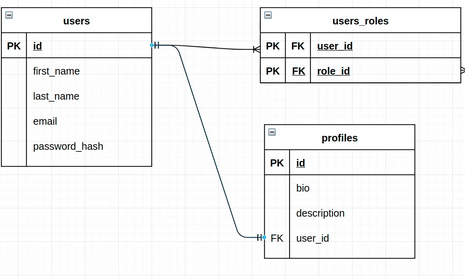

Percebe que a entidade (tabela) *users* tem uma relação com a entidade *profiles* e *user_roles*? Ou seja, tanto profiles quanto roles tem uma sigla denominada **FK** e o atributo que é guardado em FK nada mais é que **user_id**.
* Portanto, é possível perceber que `user_id` nada mais é que o **primary key** de alguma linha da tabela user e com isso, torna-se possível encontrar um determinado usuário associado.

Demonstrando isso de forma prática, observe as duas imagens:

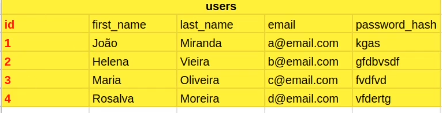

A tabela *user* tem seus atributos devidamente preenchidos, certo? Agora, observe a segunda imagem:

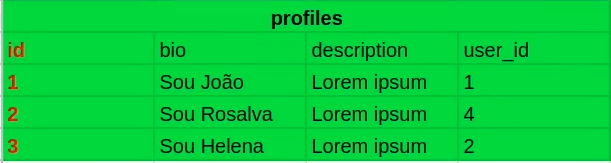

Já a tabela *profile* também tem seus dados devidamente preenchidos, porém, dessa vez **profiles** apresenta um campo a mais, sendo ele **user_id** e se você observar corretamente, os valores da primeira linha tem a ver com os valores da linha um da tabela **users**. Portanto, há uma relação entre essas duas entidades. Ademais, **user_id** guarda o primary key do João.

---

## Relacionamento entre entidades (tabelas)

### Crow's Foot Notation (notação pé de galinha)
Para representar uma relação entre entidades, como foi dito anteriormente, é utilizado a famosa notação pé de galinha, onde é possível identificar as regras daquela relação apenas olhando para as extremidades. Veja na imagem abaixo:

**O lado direito representa a cardinalidade e o lado esquerdo representa a obrigatoriedade.**

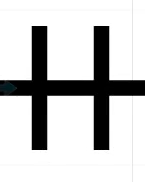

Na imagem, é possível identificar uma das extremidades da relação, onde há dois traços. Nesse caso, trata-se de uma relação **one-to-one**, mas como identifiquei isso? basicamente, há uma regra, onde:
1. Lado mais próximo da extremidade (que toca a tabela): representa o **máximo (ou cardinalidade)**.
2. Após o lado mais próximo (segundo ponto): representa o **mínimo (ou obrigatoriedade)**.

O que isso quer dizer? Nem sempre pode ser um traço. Considere que pode ser um pé de galinha (indica muitos), pode ser uma bolinha (indica como não obrigatório), etc. Portanto, pode fazer a leitura como se fosse 0 e 1, onde o 1 representa o traço.

#### Mas e como funciona esse negócio de máximo e mínimo?
Basicamente, isso indica quantas relações aquela tabela pode ter, sendo:

**1. Máximo (Cardinalidade):** pode ser apenas um traço (I) e um pé de galinha (<).
> **Obs:** Não pode ser bolinha(0)
* Caso seja um **pé de galinha (<)**: Pode ter mais de duas relações com muitas entidades
* Caso seja um **traço (I)**: Pode ter no máximo somente uma relação com uma entidade.

**2. Mínimo (Obrigatoriedade):** pode ser apenas um traço (I) e bolinha (0).
> **Obs:** Não pode ser um pé de galinha (<).
* Caso seja um **traço (I)**: Tem que ter no mínimo uma relação com uma entidade
* Caso seja **bolinha (0)**: Pode ter uma relação com uma entidade, não sendo **obrigatório**

### Relacionamento um para um (one-to-one - 1:1)

A relação de um para um indica que uma tabela tem relação com outra tabela através da notação pé de galinha (1:1 | 0:1).
* Ademais, é obrigatoriamente necessário para todos os casos de relação armazenar o **FK** na tabela **complementar** para oficializar que tabela B pertence a Tabela A.

Ademais, outra coisa que é importante é que quando a tabela A é apagada, a tabela B tem que ser apagada juntamente com a tabela A. Caso contrário, a tabela B pode sim continuar existindo, mas com informações que podem acabar não sendo mais tão úteis. Porém, em todo caso, é uma escolha sua.

> **Nota:** Por fim, uma informação que é útil é que segundo o professor, o relacionamento de **um para um** não é tão utilizado quanto o relacionamento de **um para muitos**. Isso ocorre porque por questão de desempenho e eficiencia, tem casos que o mais útil é unificar os dados da tabela A com a tabela B.

No caso do exemplo que irei apresentar, as colunas da tabela profile poderiam muito bem estar unidas com as colunas da tabela users. Agora, veja um exemplo de relação **one-to-one** abaixo:

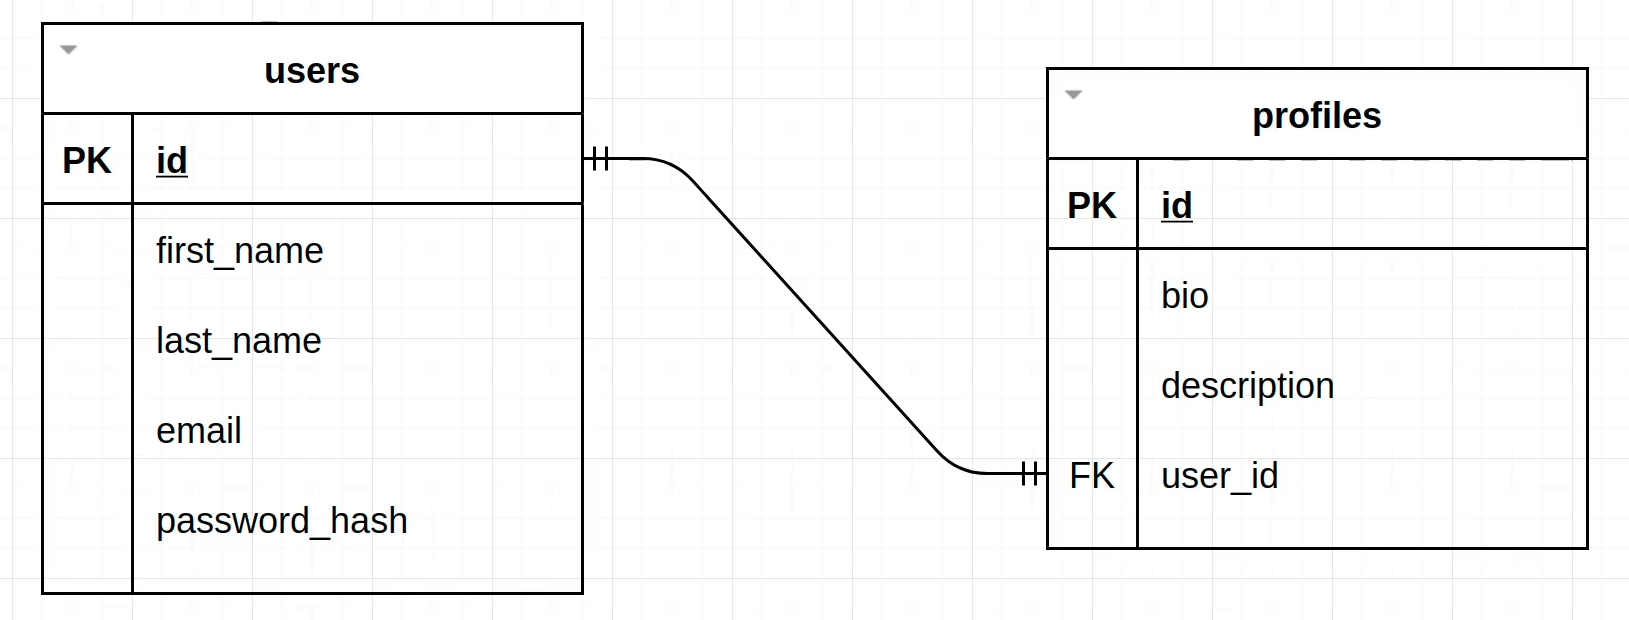

### Relacionamento de um para muitos (one-to-many - 1:N)

Basicamente, esse relacionamento se comporta de forma semelhante ao anterior, com uma diferença: ao invés de uma entidade se relacionar com apenas **uma entidade**, ela pode se relacionar com **várias entidades**, podendo ser obrigatório ou não. Veja na representação abaixo:

#### 1. Não obrigatório (0<)

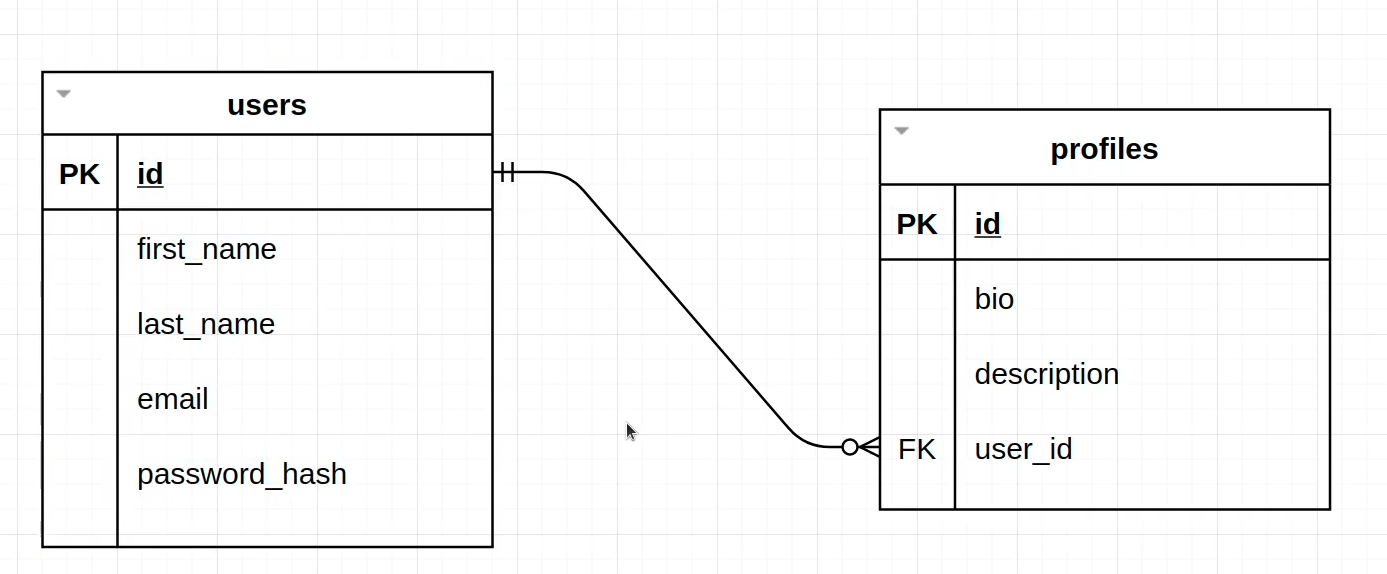

Como pode ver, a tabela entidade `user` tem que existir obrigatoriamente, porém, a tabela `profiles` permite que sua existência seja opcional. O que isso quer dizer na prática? Quer dizer que uma pessoa pode existir, mas não precisa necessariamente criar um perfil de usuário em algum lugar.

#### 2. Obrigatório (|<)

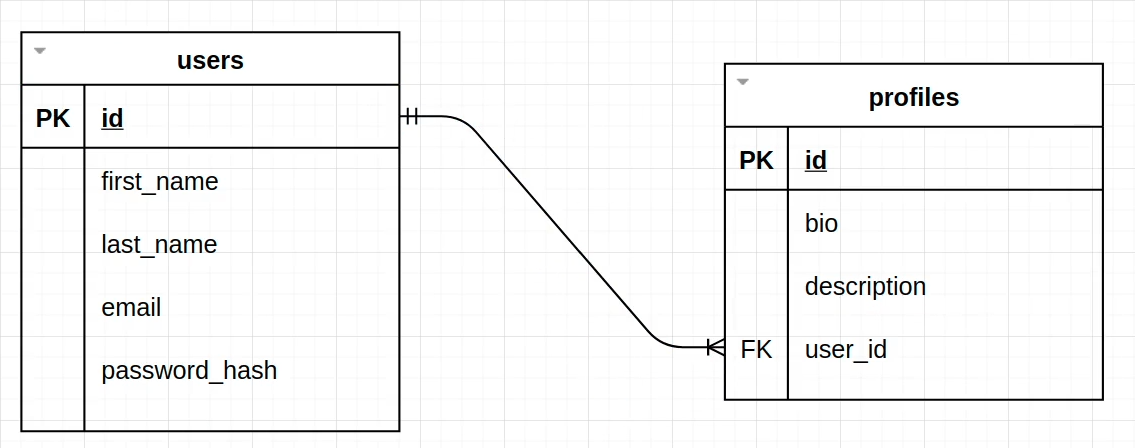

No caso acima, é possível identificar que a tabela `user` ainda é obrigatória, porém a tabela `profiles` também passou a ser obrigatória (já que o mínimo é um traço).

> **Nota:** Trata-se de uma relação obrigatória; não precisa ter mais de dois profiles para o usuário. Se tiver no mínimo um perfil, vai funcionar normalmente. Porém, se esse mesmo usuário quiser criar mais, fica a critério dele.

---

#### Como funciona exatamente?

Para entender melhor, basta pensar em uma conta em alguma rede social... como é uma relação de um para muitos, é possível imaginar um cenário onde há um usuário criando sua conta no Instagram. Porém, esse mesmo e único usuário pode finalizar a criação de sua conta e iniciar a criação de outra conta e depois de mais outra. Nesse caso, o que mudou? Apenas as contas, pois o usuário é o mesmo.



> **Nota:** Uma coisa que não é permitida é ter o foreign key da tabela A na B e a B na A. É em um lado ou no outro. No caso de um relacionamento **one-to-many**, é importante que nesse relacionamento a **foreign key sempre fique no lado de many (muitos)**. Ou seja, cada uma das entidades de **many** deverão ter a primary key do lado de **one**.